In [38]:
import os
import pandas as pd
import numpy as np

repo_root = !git rev-parse --show-toplevel
repo_root = repo_root[0]
os.chdir(repo_root)

# Input structure
input_dir = "data/NUP98/input"
input_pdb = os.path.join(input_dir, "021structure.pdb")
receptor_ligand_chains = ["A", "B"]
receptor_ligand_pdb = os.path.join(input_dir, "021structure_AB.pdb")


# Search results
results_dir = "data/NUP98/search_results"
postprocess_dir = os.path.join(results_dir, "postprocess")

# Path to postprocessed csv
postprocess_csv_path = os.path.join(results_dir, "021structure_C_mimicry_postprocessed.csv")

# Path to uniprot_to_exclude_csv
uniprot_to_exclude_csv = "/work/upthomae/Meng/uniprot_to_exclude_17of23_251015.csv"

In [34]:
# Load all postprocess CSVs into a single DataFrame
df_postprocess = pd.DataFrame()
for file in os.listdir(postprocess_dir):
    if file.endswith('.csv'):
        df = pd.read_csv(os.path.join(postprocess_dir, file))
        df_postprocess = pd.concat([df_postprocess, df])

print(f"df_postprocess.shape {df_postprocess.shape}")

df_postprocess.shape (19418, 85)


In [35]:
pd.set_option('display.max_rows', None)
df_postprocess.iloc[0]

P1_id                                                           A6NKT7-F1-TED06_A
P2_id                                                           021structure_C_AB
P1_source_ppi_id                                                               p1
P2_source_ppi_id                                                               p1
P1_source_site                                                               2148
P2_source_site                                                               3180
P1_source_TMscore                                                         0.26423
P2_source_TMscore                                                         0.17875
P1_source_iface                                                          0.268085
P2_source_iface                                                          0.601538
MaSIF-score                                                              0.480783
flattened_transform             0.8733732986921803,-0.4396214743916047,0.20964...
ca_clash        

In [36]:
# add domain_length column by counting the number of characters in domain_seq
df_postprocess['domain_length'] = df_postprocess['domain_seq'].apply(len)
df_postprocess.iloc[0]

P1_id                                                           A6NKT7-F1-TED06_A
P2_id                                                           021structure_C_AB
P1_source_ppi_id                                                               p1
P2_source_ppi_id                                                               p1
P1_source_site                                                               2148
P2_source_site                                                               3180
P1_source_TMscore                                                         0.26423
P2_source_TMscore                                                         0.17875
P1_source_iface                                                          0.268085
P2_source_iface                                                          0.601538
MaSIF-score                                                              0.480783
flattened_transform             0.8733732986921803,-0.4396214743916047,0.20964...
ca_clash        

In [39]:
# Filter by uniprot_to_exclude_csv
df_uniprot_to_exclude = pd.read_csv(uniprot_to_exclude_csv)
uniprot_to_exclude = df_uniprot_to_exclude[df_uniprot_to_exclude['uniprot_excluded'] == 1]['uniprot_accn'].tolist()
n_row_before = len(df_postprocess)
df_postprocess = df_postprocess[~df_postprocess['uniprot_accn'].isin(uniprot_to_exclude)]
n_row_after = len(df_postprocess)
print(f"Filtered by uniprot_to_exclude:")
print(f"n_row_before: {n_row_before}, n_row_after: {n_row_after}")

Filtered by uniprot_to_exclude:
n_row_before: 19418, n_row_after: 19330


In [40]:
# Write to postprocess_csv_path
df_postprocess.to_csv(postprocess_csv_path, index=False)

In [41]:
from Bio.PDB import PDBIO, PDBParser, StructureBuilder
from Bio.PDB.Structure import Structure
from Bio.PDB.Model import Model

parser = PDBParser()
struct = parser.get_structure("021structure", input_pdb)

# create a new structure and model to hold selected chains
new_struct = Structure("receptor_ligand")
model = Model(0)
new_struct.add(model)

for chain_id in receptor_ligand_chains:
    chain = struct[0][chain_id]
    # Clone the chain to avoid problems when writing out
    import copy
    model.add(copy.deepcopy(chain))

io = PDBIO()
io.set_structure(new_struct)
io.save(receptor_ligand_pdb)

/home/ymeng/miniconda3/envs/MaSIF/lib/python3.11/site-packages/Bio/PDB/PDBParser.py:384: PDBConstructionWarning: Ignoring unrecognized record 'END' at line 6610
  warnings.warn(


___

Text(0.5, 0, 'Cluster Size')

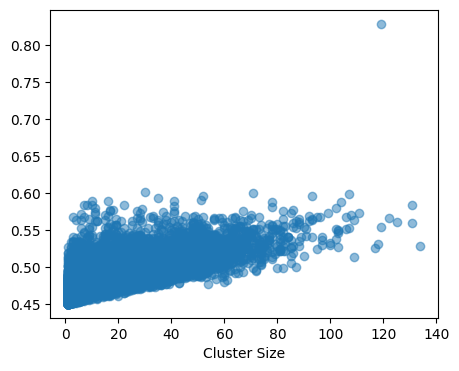

In [6]:
# Plot cluster_size ~ MaSIF-score
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
plt.scatter(df_postprocess['cluster_size'], df_postprocess['MaSIF-score'], alpha=0.5)
plt.xlabel('Cluster Size')

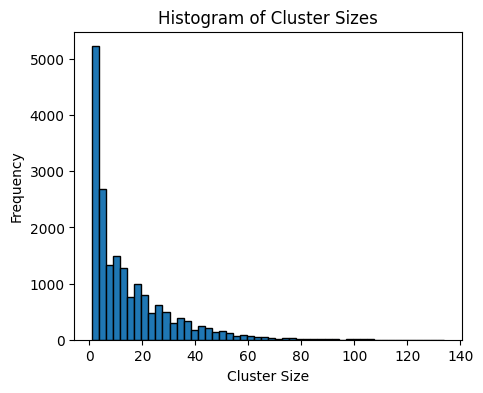

In [7]:
# Plot a histogram of cluster_size
plt.figure(figsize=(5, 4))
plt.hist(df_postprocess['cluster_size'], bins=50, edgecolor='black')
plt.xlabel('Cluster Size')
plt.ylabel('Frequency')
plt.title('Histogram of Cluster Sizes')
plt.show()


___
### Libary 1 - domains below 102 a.a. (350 nt)

In [49]:
filtered_library_csv = os.path.join(results_dir, "021structure_C_mimicry_postprocessed_filtered_102aa_260522.csv")

df_library = pd.read_csv(filtered_library_csv)

df_library.iloc[0]


P1_id                                                           O76050-F1-TED03_A
P2_id                                                           021structure_C_AB
P1_source_ppi_id                                                               p1
P2_source_ppi_id                                                               p1
P1_source_site                                                                361
P2_source_site                                                               2975
P1_source_TMscore                                                         0.31045
P2_source_TMscore                                                         0.15887
P1_source_iface                                                          0.886966
P2_source_iface                                                          0.565824
MaSIF-score                                                              0.497169
flattened_transform             -0.2017800792358872,0.5528490050322867,-0.8084...
ca_clash        

In [50]:
def fill_library_sequence(row, target_length=102, verbose=True):
    """
    Extend domain to target_length by adding contiguous UniProt residues from full_sequence
    at N- and C-termini of domain_seq (which is assumed contiguous in UniProt).
    """
    uniprot_seq = row['full_sequence']
    full_seq_length = len(uniprot_seq)

    # domain_resi: 1-based residue indices in full_sequence, may be gapped
    domain_resi = [int(r) for r in str(row['resi']).split(',')]
    # domain_seq: contiguous, from full_sequence, corresponding to the above resi
    domain_seq = row['domain_seq'] if 'domain_seq' in row else row['sequence']
    domain_seq_len = len(domain_seq)

    # If protein too short, just take everything
    if full_seq_length <= target_length:
        domain_resi_filled = list(range(1, full_seq_length + 1))
        return domain_resi_filled, uniprot_seq

    n_to_add = target_length - domain_seq_len
    n_before = n_to_add // 2
    n_after = n_to_add - n_before

    # Position of domain in full sequence
    dom_start = domain_resi[0]    # 1-based
    dom_end = domain_resi[-1]     # 1-based

    # Because domain_seq assumed contiguous, domain_resi must also be contiguous
    # extend before and after
    seq_before_start = max(1, dom_start - n_before)
    seq_after_end = min(full_seq_length, dom_end + n_after)

    actual_n_before = dom_start - seq_before_start
    actual_n_after = seq_after_end - dom_end

    # If not enough space at N-term, shift C-term
    if actual_n_before < n_before:
        needed = n_before - actual_n_before
        possible_add = min(needed, full_seq_length - seq_after_end)
        seq_after_end += possible_add
        actual_n_after = seq_after_end - dom_end

    # If not enough space at C-term, shift N-term
    if actual_n_after < n_after:
        needed = n_after - actual_n_after
        possible_add = min(needed, seq_before_start - 1)
        seq_before_start -= possible_add

    seq_add_before = uniprot_seq[seq_before_start - 1 : dom_start - 1]
    seq_add_after = uniprot_seq[dom_end : seq_after_end]
    library_seq = seq_add_before + domain_seq + seq_add_after

    # Build domain_resi_filled as: residues before + domain + residues after (all as 1-based indices)
    resi_before = list(range(seq_before_start, dom_start))            # residues added before
    resi_after = list(range(dom_end + 1, seq_after_end + 1))          # residues added after
    domain_resi_filled = resi_before + domain_resi + resi_after

    if verbose:
        print(f"domain_seq: {domain_seq}")
        print(f"Adding before: seq[{seq_before_start}:{dom_start - 1}] | '{seq_add_before}' (len {len(seq_add_before)})")
        print(f"Adding after: seq[{dom_end + 1}:{seq_after_end}]   | '{seq_add_after}' (len {len(seq_add_after)})")
        print(f"Total library_seq length: {len(library_seq)} | domain_resi_filled: {domain_resi_filled[0]}-{domain_resi_filled[-1]}")

    # domain_seq must lie inside library_seq
    domain_seq_start_idx = len(seq_add_before)
    assert library_seq[domain_seq_start_idx : domain_seq_start_idx + domain_seq_len] == domain_seq

    return domain_resi_filled, library_seq

row = df_library.iloc[19]
target_length = 102
domain_resi = [int(r) for r in str(row['resi']).split(',')]

domain_resi_filled, library_seq = fill_library_sequence(row, target_length, verbose=True)

print(f"domain resi: {domain_resi}")
print(f"domain_resi_filled: {domain_resi_filled}")
print(f"filled span: {domain_resi_filled[0]}-{domain_resi_filled[-1]} ({len(domain_resi_filled)} aa)")
print(f"library_seq length: {len(library_seq)}")
assert len(library_seq) == target_length
assert len(domain_resi_filled) == target_length
# TED sequence must lie inside library_seq
ted_offset = domain_resi[0] - domain_resi_filled[0]
assert library_seq[ted_offset : ted_offset + len(row['sequence'])] == row['sequence']
print(f"library_seq:\n{library_seq}")


domain_seq: FLRGFVQIGNCKTGISKSKEAFIEAVERKKKDRLVLYFKSGKYSTFRLSDNIQNVVLKSYRGNQNHLHLTLQNNNGLFIEGLSSTDAEQLKIFLDRVHQNE
Adding before: seq[5:4] | '' (len 0)
Adding after: seq[106:106]   | 'V' (len 1)
Total library_seq length: 102 | domain_resi_filled: 5-106
domain resi: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105]
domain_resi_filled: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 8

In [51]:
# Apply to all rows
df_library['domain_resi_library'], df_library['library_seq'] = zip(*df_library.apply(fill_library_sequence, axis=1))

df_library.iloc[0]


domain_seq: DECTICYEHAVDTVIYTCGHMCLCYACGLRLKKALHACCPICRRPIKDIIKTYRSS
Adding before: seq[473:518] | 'LGSRLSDPLLSTCSSGPLGSSAGGTAPNSPVSLPESPVTPGLGQWS' (len 46)
Adding after: seq[575:574]   | '' (len 0)
Total library_seq length: 102 | domain_resi_filled: 473-574
domain_seq: LFLTNLPEETNELMLSMLFNQFPGFKEVRLVPGRHDIAFVEFDNEVQAGAARDALQGFKITQNNAMKISFA
Adding before: seq[181:209] | 'PPGAMPPQQLMPGQMPPAQPLSENPPNHI' (len 29)
Adding after: seq[281:282]   | 'KK' (len 2)
Total library_seq length: 102 | domain_resi_filled: 181-282
domain_seq: CKICMDRNIAIVFVPCGHLVTCKQCAEAVDKCPMCYTVITFKQKI
Adding before: seq[396:449] | 'KIQISGSNYKSLEVLVADLVNAQKDSMQDESSQTSLQKEISTEEQLRRLQEEKL' (len 54)
Adding after: seq[495:497]   | 'FMS' (len 3)
Total library_seq length: 102 | domain_resi_filled: 396-497
domain_seq: DRLTISYCRSSGPGGQNVNKVNSKAEVRFHLATAEWIAEPVRQKIAITHKNKINRLGELILTSESSRYQFRNLADCLQKIRDMITEASQ
Adding before: seq[69:74] | 'DSDIPL' (len 6)
Adding after: seq[164:170]   | 'TPKEPTK' (len 7)
Total library_seq length: 1

P1_id                                                           O76050-F1-TED03_A
P2_id                                                           021structure_C_AB
P1_source_ppi_id                                                               p1
P2_source_ppi_id                                                               p1
P1_source_site                                                                361
P2_source_site                                                               2975
P1_source_TMscore                                                         0.31045
P2_source_TMscore                                                         0.15887
P1_source_iface                                                          0.886966
P2_source_iface                                                          0.565824
MaSIF-score                                                              0.497169
flattened_transform             -0.2017800792358872,0.5528490050322867,-0.8084...
ca_clash        

In [52]:
import re
import subprocess
import tempfile
from pathlib import Path

CDHIT_IDENTITY = 0.95  # 1.0 = exact matches only; 0.95 removes near-duplicate 102-mers
CDHIT_WORD_SIZE = 5    # required for -c >= 0.7 with cd-hit


def parse_cd_hit_clstr(clstr_path):
    """Return list of clusters; each cluster is a list of integer FASTA header ids."""
    clusters = []
    current = []
    with open(clstr_path) as fh:
        for line in fh:
            line = line.rstrip()
            if line.startswith(">Cluster"):
                if current:
                    clusters.append(current)
                current = []
            elif line:
                # e.g. "0\t130aa, >42... *" — FASTA id is after '>'
                m = re.search(r">(\d+)", line)
                if not m:
                    raise ValueError(f"Could not parse cd-hit clstr line: {line!r}")
                current.append(int(m.group(1)))
        if current:
            clusters.append(current)
    return clusters


def deduplicate_df_library_cdhit(df, seq_col="library_seq", score_col="MaSIF-score", identity=CDHIT_IDENTITY):
    """Cluster library_seq with cd-hit; keep highest MaSIF-score row per cluster."""
    df = df.reset_index(drop=True)
    n_before = len(df)

    with tempfile.TemporaryDirectory(prefix="cdhit_library_") as tmpdir:
        tmpdir = Path(tmpdir)
        fasta_in = tmpdir / "library.fa"
        with open(fasta_in, "w") as fh:
            for i, seq in enumerate(df[seq_col]):
                fh.write(f">{i}\n{seq}\n")

        fasta_out = tmpdir / "library_cdhit"
        cmd = [
            "cd-hit",
            "-i", str(fasta_in),
            "-o", str(fasta_out),
            "-c", str(identity),
            "-n", str(CDHIT_WORD_SIZE),
            "-d", "0",
            "-M", "0",
        ]
        subprocess.run(cmd, check=True, capture_output=True, text=True)

        clusters = parse_cd_hit_clstr(Path(f"{fasta_out}.clstr"))

    keep_rows = []
    for member_ids in clusters:
        sub = df.iloc[member_ids]
        keep_rows.append(sub[score_col].idxmax())

    df_dedup = df.loc[sorted(keep_rows)].copy()
    n_multi = sum(1 for c in clusters if len(c) > 1)
    print(
        f"CD-HIT (-c {identity}): {n_before} -> {len(df_dedup)} rows "
        f"({n_before - len(df_dedup)} removed, {n_multi} multi-member clusters)"
    )
    return df_dedup


n_before = len(df_library)
df_library = deduplicate_df_library_cdhit(df_library)
assert df_library["library_seq"].is_unique
print(f"unique library_seq: {df_library['library_seq'].nunique()} / {len(df_library)}")

CD-HIT (-c 0.95): 2367 -> 2339 rows (28 removed, 20 multi-member clusters)
unique library_seq: 2339 / 2339


In [53]:
# Filter to 2000 rows with highest MaSIF-score
df_library = df_library.sort_values(by='MaSIF-score', ascending=False).head(2000)
df_library.iloc[0]

# Save filtered library
filtered_library_csv = os.path.join(results_dir, "021structure_C_mimicry_library_102aa_260522.csv")
df_library.to_csv(filtered_library_csv, index=False)

In [54]:
# Select only the relevant columns for readability
df_library_seq = df_library[['P1_id', 'MaSIF-score', 'num_gaps', 'linker_types', 'linker_seqs', 'domain_seq', 'domain_length','domain_resi_library', 'library_seq']]
df_library_seq.iloc[0]


P1_id                                                  O75970-F1-TED05_A
MaSIF-score                                                     0.598747
num_gaps                                                               0
linker_types                                                         NaN
linker_seqs                                                          NaN
domain_seq             KQEAALLTKWQRIMGINYEIVVAHVSKFSENSGLGISLEATVGHHF...
domain_length                                                        102
domain_resi_library    [532, 533, 534, 535, 536, 537, 538, 539, 540, ...
library_seq            KQEAALLTKWQRIMGINYEIVVAHVSKFSENSGLGISLEATVGHHF...
Name: 950, dtype: object

In [55]:
# Save filtered library
library_csv = os.path.join(results_dir, "021structure_C_mimicry_library_102aa_260522_sequences.csv")
df_library_seq.to_csv(library_csv, index=False)
